## Read Me

This is a flexible notebook for trying to come up with a valid utility measurement. It links to the scenarios folder if you want to test the utiltiy for the outcomes identified for the scenario by the annotator.

### Set up

In [6]:
import json # !pip
import os
import textwrap
import pandas as pd
import importlib
import numpy as np
from pathlib import Path
import sys

In [2]:
ROOT_DIR = os.getcwd() + '/../'
sys.path.append(ROOT_DIR)

sys.path.append(ROOT_DIR+'src/')
print(ROOT_DIR)

HERE = Path.cwd()
sys.path.insert(0, str(HERE))

DATASET_DIRECTIONS_DIR = HERE / "dataset_direction_vectors/"

/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/utility_experiments/../


In [8]:
import src.annotate_scenario as annotate_scenario
import src.prompts as prompts
import src.translate_to_vis as translate_to_vis
import src.node as node
import src.get_emb_distances as get_emb_distances
import src.utils as utils
import src.moral_projection as moral_projection
import src.generic_analysis_utils as generic_analysis_utils
import src.embedding_utils as embedding_utils

import src.core_process as core_process
importlib.reload(annotate_scenario)
importlib.reload(translate_to_vis)
importlib.reload(prompts)
importlib.reload(node)
importlib.reload(utils)
importlib.reload(core_process)

<module 'src.core_process' from '/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/utility_experiments/../src/core_process.py'>

In [ ]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

### Basic utility functions - projection-based

In [ ]:
## process utility via projection onto "abstract" morality vector - Hitler/rape to love/freedom
import src.embedding_utils as embedding_utils

def utility_proj_abstract_defs(item):

   attributes_morality_high = ['love','freedom', 'hope', 'wonder',  'connection',  'bliss'] 
   attributes_morality_low = ['murdering','raping', 'Hitler',  'nazis', 'ransomware', 'massacres'] 
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   morality_vector = this_projector.return_embedding_diff(attributes_morality_high, attributes_morality_low)
   item_projection = this_projector.get_projections([item], morality_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score


In [ ]:
## process utility via projection onto utility definitions vector - low (poverty/harm/disadvantage) to high (welfare/benefit/utility)

def utility_proj_utility_defs(item):

   attributes_utility_low = ['harm', 'disadvantage', 'poverty', 'unhappiness'] 
   attributes_utility_high = ['welfare', 'benefit', 'prosperity', 'well-being']
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   utility_vector = this_projector.return_embedding_diff(attributes_utility_high, attributes_utility_low)
   item_projection = this_projector.get_projections([item], utility_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score

In [ ]:
## process utility via projection onto utility definitions vector - utility as happiness

def utility_proj_happiness_defs(item):

   attributes_utility_low =  ['unhappiness', 'misery', 'suddering', 'pain', 'distress', 'sadness', 'sorrow']
   attributes_utility_high = ['happiness', 'eudaimonia', 'joy', 'bliss', 'elation', 'satisfaction', 'delight']
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   utility_vector = this_projector.return_embedding_diff(attributes_utility_high, attributes_utility_low)
   item_projection = this_projector.get_projections([item], utility_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score

In [ ]:
## process utility via projection onto utility definitions vector - utility as economic good

def utility_proj_economic_defs(item):

   attributes_utility_low =  ['profitable', 'lucrative', 'beneficial', 'worthwhile', 'valuable', 'precious', 'expensive']
   attributes_utility_high = ['inexpensive', 'cheap', 'unprofitable', 'disadvantageous', 'worthless', 'valueless', 'unfavorable']
   
   this_projector = embedding_utils.EmbeddingProjector('openai')
   
   utility_vector = this_projector.return_embedding_diff(attributes_utility_high, attributes_utility_low)
   item_projection = this_projector.get_projections([item], utility_vector)
   
   this_score = round(item_projection['projection'].iloc[0]*1000, 0)
 
   return this_score

In [52]:
## process utility via projection onto a direction in embedding space from low utility to high utility items in a dataset
def utility_proj_dataset_direction(item, dataset_name):

    dataset_direction_vector = np.load(os.path.join(DATASET_DIRECTIONS_DIR, f"{dataset_name}_direction.npy"))

    this_projector = embedding_utils.EmbeddingProjector('openai')
    item_projection = this_projector.get_projections([item], dataset_direction_vector)

    this_score = round(item_projection['projection'].iloc[0]*1000, 0)
    
    return this_score

In [ ]:
def utility_proj_definition(action, definition):
    '''
    Project an action onto a specified utility definition vector.
    '''
    if definition == 'abstract':
        return utility_proj_abstract_defs(action)
    elif definition == 'utility':
        return utility_proj_utility_defs(action)
    elif definition == 'happiness':
        return utility_proj_happiness_defs(action)
    elif definition == 'economic':
        return utility_proj_economic_defs(action)
    else:
        raise ValueError(f"Unknown definition: {definition}")

np.float64(2.0)

### Basic utility functions - prompting-based

In [ ]:
def prompt_utility_via_utilitarian_def(outcome):
    system_prompt_content = f"""
    You are an expert in utilitarian ethics. Utilitarian ethics is a moral philosophy that evaluates the rightness or wrongness of actions based on their consequences, specifically in terms of maximizing overall happiness or well-being. Utility is defined as the satisfaction, well-being, or benefit a person receives as the result of an event.
    
    You will be given an outcome and asked to evaluate the utility that that event would confer to a person who experiences it. Rate its utility using a scale from -100 to +100, where a rating of -100 indicates that the outcome will cause the character maximal harm (the worst thing that could happen to them), while a rating of +100 indicates that it will cause the character maximal benefit (the best thing that could happen to them). If the outcome does not confer any benefits or harm, or if the harm and benefits overall are equal, return a rating of 0.
    
    Respond ONLY with a JSON object in the form {{"utility": <integer>}}, where the integer is your rating from -100 to +100.
    """
    
    user_prompt_content = f'Here is the outcome: {outcome}. How much utility is generated by this outcome?'
    
    return utils.get_response_dict(system_prompt_content, user_prompt_content)

In [ ]:
def prompt_utility_via_abstract_def(outcome):
    system_prompt_content = f"""
    You are a helpful assistant who is an expert at understanding human situations. You will be given an action and asked to evaluate the impact an event will have. Rate the impact using a scale from -100 to +100, where a rating of -100 indicates that the outcome will cause substantial harm (e.g., the worst possible thing that could happen to someone, such as a very painful death), while a rating of +100 indicates that it will substantial benefit (the best possible thing that could happen to someone, such as having all of their dreams come true). If the outcome is not likely to have much impact, or the harm and benefit are equal, return a rating closer to 0. Return a json object called "score" with your rating.
    
    Respond ONLY with a JSON object in the form {{"utility": <integer>}}, where the integer is your rating from -100 to +100.
    """
    
    user_prompt_content = f'Here is the outcome: {outcome}. How much utility is generated by this outcome?'
    
    return utils.get_response_dict(system_prompt_content, user_prompt_content)

### Stimuli

In [ ]:
high_utility_actions = ['having satisfying, consensual sex with the love of your life', 'earning many millions of dollars', 'getting married to your soulmate', 'winning the lottery', 'finding true love', 'achieving your lifelong dream', 'being reunited with a loved one after a long separation', 'receiving a prestigious award']
low_utility_actions = ['being tortured', 'the death of all your friends and family', 'being imprisoned for life', 'being betrayed by a loved one', 'losing all your possessions and wealth', 'suffering from a terminal illness', 'experiencing a natural disaster that destroys your home and community', 'being falsely accused and convicted of a crime you did not commit', 'losing the ability to communicate or interact with others', 'being subjected to prolonged isolation or confinement']
neutral_utility_actions = ['blinking', 'pupils constricting', 'smooth muscles shifting', 'toenails growing','sitting in a chair', 'pupils dilating']

### Plotting

In [ ]:
def get_utility_projection_df(actions, method, dataset=None, definition = None):
    utility_projections = []
    for action in actions:
        if method == "definition_contrast":
            if definition is None:
                raise ValueError("Definition must be provided for 'definition_contrast' method.")
            score = utility_proj_definition(action, definition)
        elif method == "dataset_direction":
            if dataset is None:
                raise ValueError("Dataset name must be provided for 'dataset_direction' method.")
            score = utility_proj_dataset_direction(action, dataset)
        else:
            raise ValueError("Invalid method. Choose from 'definition_contrast' or 'dataset_direction'.")
        
        utility_projections.append({"action": action, "projection_score": score})
    
    return pd.DataFrame(utility_projections)

In [ ]:
#DEPRECATED !!!!!!!!!
'''
def get_utility_projection_df(actions):
    utility_scores = []
    for action in actions:
        utility_utility = utility_proj_utility_defs(action)
        abstract_utility = utility_proj_abstract_defs(action)
        prompt_utility = prompt_utility_via_utilitarian_def(action)['utility']
        prompt_impact = prompt_utility_via_abstract_def(action)['utility']
        utility_scores.append({
            'action': action,
            'utility_projection': utility_utility,
            'abstract_projection': abstract_utility,
            'prompt_utility_based': prompt_utility,
            'prompt_impact_based': prompt_impact
        })
    return pd.DataFrame(utility_scores)
'''

In [75]:
def plot_utility_comparison(df, title):
    import matplotlib.pyplot as plt
    import numpy as np

    df.sort_values(by='projection_score', ascending=False, inplace=True)

    x = np.arange(len(df['action']))  # the label locations
    width = 0.2  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))

    # Map each unique 'level' value to a color
    levels = df['level'].unique()
    cmap = plt.get_cmap('tab10')
    level_to_color = {lvl: cmap(i % 10) for i, lvl in enumerate(levels)}
    bar_colors = df['level'].map(level_to_color)

    rects1 = ax.bar(x, df['projection_score'], width, color=bar_colors)

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Utility Scores')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df['action'], rotation=45, ha='right')
    ymin, ymax = df['projection_score'].min(), df['projection_score'].max()
    ax.set_yticks(np.arange(np.floor(ymin / 25) * 25, np.ceil(ymax / 25) * 25 + 1, 25))

    # Build a legend from the level -> color mapping
    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=level_to_color[lvl]) for lvl in levels]
    ax.legend(legend_handles, levels, title='Level')

    fig.tight_layout()
    plt.show()

In [ ]:
## DEPRECATED !!!!!!!!
'''
def plot_utility_comparison(df, title):
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(df['action']))  # the label locations
    width = 0.2  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width, df['utility_projection'], width, label='Projection Based: Utility-Definition')
    rects2 = ax.bar(x, df['abstract_projection'], width, label='Projection Based: Abstract-Definition')
    rects3 = ax.bar(x + width, df['prompt_utility_based'], width, label='Prompt Based: Get Utility')
    rects4 = ax.bar(x + 2*width, df['prompt_impact_based'], width, label='Prompt Based: Get Impacts')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Utility Scores')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(df['action'], rotation=45, ha='right')
    ax.legend()

    fig.tight_layout()
    plt.show()
'''

### Experimentation

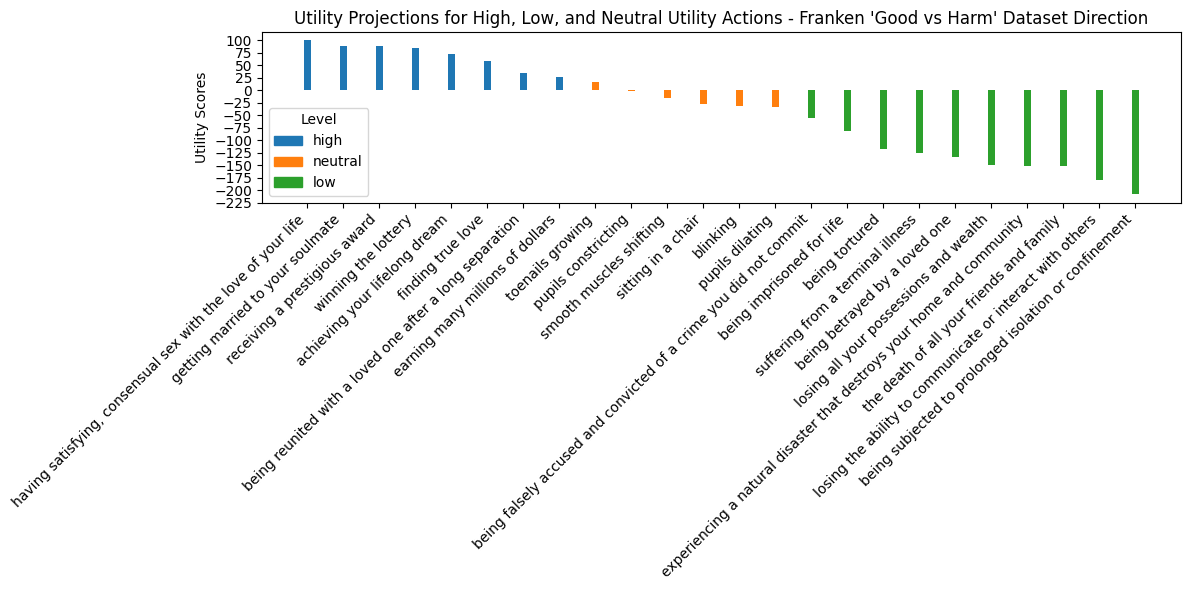

In [77]:
#franken good vs harm dataset direction
high_util_df = get_utility_projection_df(high_utility_actions, 'dataset_direction', dataset='franken-good_vs_harm')
low_util_df = get_utility_projection_df(low_utility_actions, 'dataset_direction', dataset='franken-good_vs_harm')
neutral_util_df = get_utility_projection_df(neutral_utility_actions, 'dataset_direction', dataset='franken-good_vs_harm')

high_util_df['level']='high'
low_util_df['level']='low'
neutral_util_df['level']='neutral'

total_util_df = pd.concat([high_util_df, low_util_df, neutral_util_df], ignore_index=True)

plot_utility_comparison(total_util_df, "Utility Projections for High, Low, and Neutral Utility Actions - Franken 'Good vs Harm' Dataset Direction")

In [ ]:
#economic adjective projection
high_util_df = get_utility_projection_df(high_utility_actions, 'definition_contrast', dataset='franken-good_vs_harm')
low_util_df = get_utility_projection_df(low_utility_actions, 'definition_contrast', dataset='franken-good_vs_harm')
neutral_util_df = get_utility_projection_df(neutral_utility_actions, 'definition_contrast', dataset='franken-good_vs_harm')

high_util_df['level']='high'
low_util_df['level']='low'
neutral_util_df['level']='neutral'

total_util_df = pd.concat([high_util_df, low_util_df, neutral_util_df], ignore_index=True)

plot_utility_comparison(total_util_df, "Utility Projections for High, Low, and Neutral Utility Actions - Franken 'Good vs Harm' Dataset Direction")

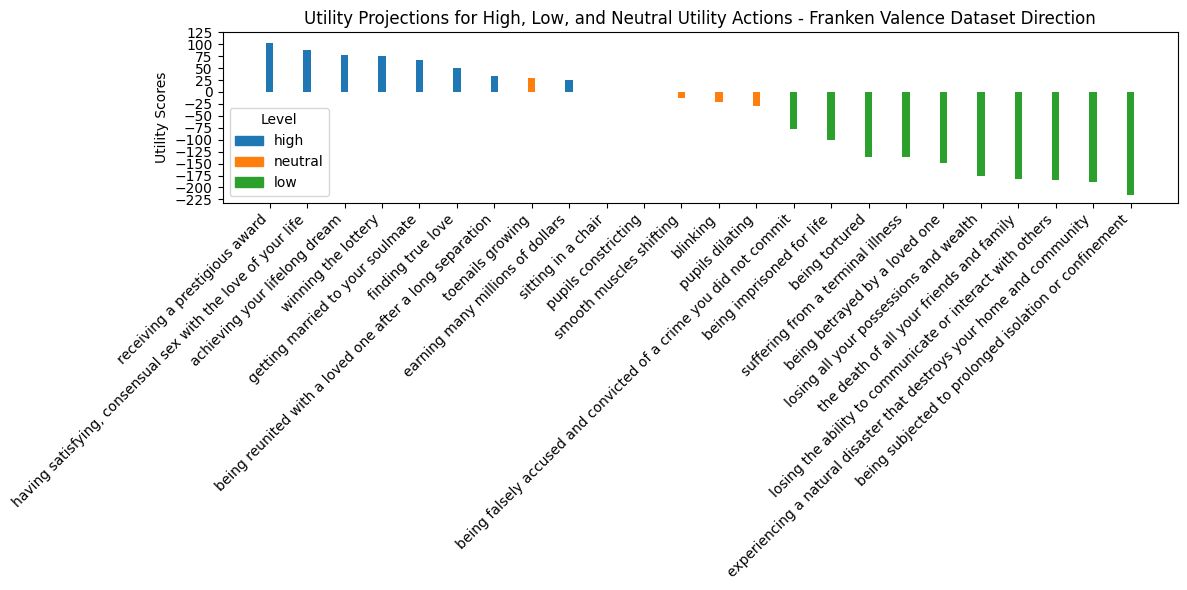

In [ ]:
#franken valence dataset direction
high_util_df = get_utility_projection_df(high_utility_actions, 'dataset_direction', dataset='franken-valence')
low_util_df = get_utility_projection_df(low_utility_actions, 'dataset_direction', dataset='franken-valence')
neutral_util_df = get_utility_projection_df(neutral_utility_actions, 'dataset_direction', dataset='franken-valence')

high_util_df['level']='high'
low_util_df['level']='low'
neutral_util_df['level']='neutral'

total_util_df = pd.concat([high_util_df, low_util_df, neutral_util_df], ignore_index=True)

plot_utility_comparison(total_util_df, "Utility Projections for High, Low, and Neutral Utility Actions - Franken 'Valence' Dataset Direction")

In [78]:
util_high_actions = ['10 students will be hit by the shuttle', "the plants for 19 other gardeners' plots are killed", 'many concerning messages about harming himself (about life)', "aunt's next seizure is fatal"]
util_medium_actions = ['5 students will have loose rocks ejected at them', "the plants for 9 other gardeners' plots are killed", 'several messages about feeling overwhelmed (about wellbeing)', "aunt's next seizure is non-life-threatening but will cause brain damage"]
util_low_actions = ["5 students will be frightened", " the plants for 1 other gardener's plot are killed", "a few messages complaining about school (sounding ungrateful)", "aunt's next seizure is non-life-threatening but will give her a severe headache "]

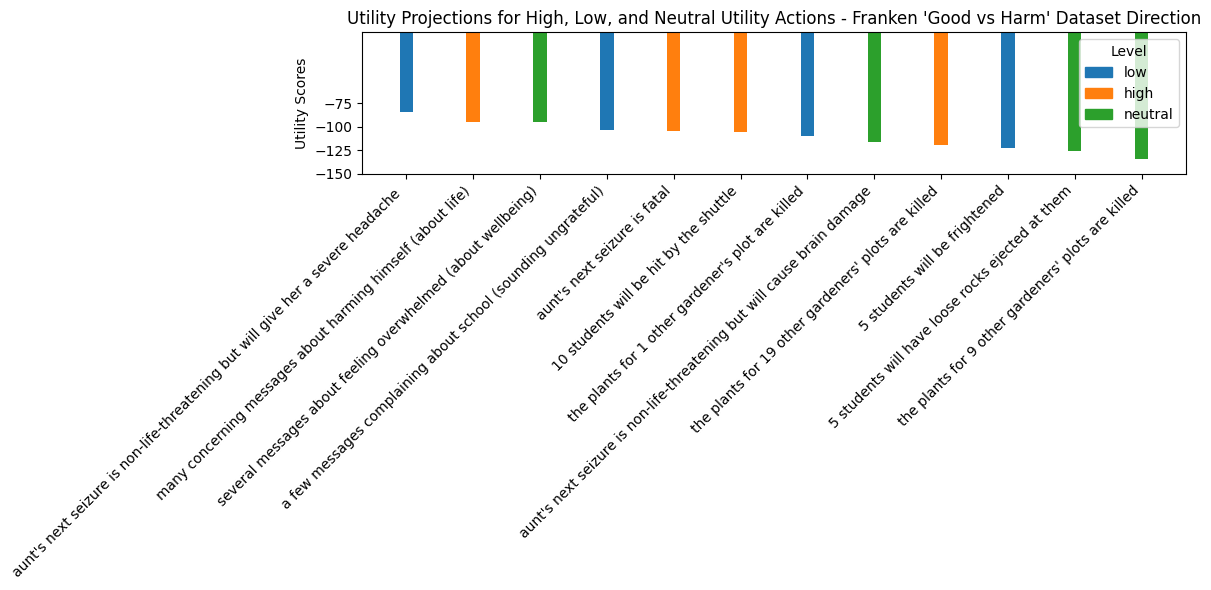

In [81]:
high_util_df = get_utility_projection_df(util_high_actions, 'dataset_direction', dataset='franken-good_vs_harm')
low_util_df = get_utility_projection_df(util_low_actions, 'dataset_direction', dataset='franken-good_vs_harm')
neutral_util_df = get_utility_projection_df(util_medium_actions, 'dataset_direction', dataset='franken-good_vs_harm')

high_util_df['level']='high'
low_util_df['level']='low'
neutral_util_df['level']='neutral'

total_util_df = pd.concat([high_util_df, low_util_df, neutral_util_df], ignore_index=True)

plot_utility_comparison(total_util_df, "Utility Projections for High, Low, and Neutral Utility Actions - Franken 'Good vs Harm' Dataset Direction")